In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
COVARIATE = "heat_index" # temp or heat_index


INPUT_FILE = f"../data/{COVARIATE}/{COVARIATE}_ccf.csv"
OUTPUT_FILE = f"../plots/ccf/{COVARIATE}_ccf.png"

df = pd.read_csv(INPUT_FILE, index_col = 0)
df

,lags,Region.1,Region.2,Region.3,Region.4,Region.5,Region.6,Region.7,Region.8,Region.9,Region.10
1,-29,0.012781,-0.008230,0.006200,-0.029691,-0.043713,0.006649,-0.013319,-0.004598,-0.004511,0.031470
2,-28,0.008610,-0.018267,-0.006689,-0.012551,-0.069075,0.006315,-0.026248,0.009932,-0.006925,0.047336
3,-27,-0.014315,-0.013183,-0.003851,0.007061,-0.077375,0.012230,-0.033269,0.013157,-0.003175,0.063127
4,-26,-0.055225,-0.029087,-0.005739,0.018997,-0.081155,0.020136,-0.045518,0.009714,0.001272,0.065702
5,-25,-0.078838,-0.048548,-0.015402,0.018920,-0.086933,0.024768,-0.050574,-0.008356,0.015495,0.049482
6,-24,-0.044615,-0.042086,-0.028680,0.012815,-0.075918,0.018034,-0.034487,-0.019890,0.033246,0.028334
7,-23,0.000180,-0.033552,-0.018112,0.009641,-0.059577,0.005663,-0.014589,-0.028055,0.041870,0.019599
8,-22,0.005097,-0.041054,-0.033338,0.004182,-0.041911,-0.001988,0.006051,-0.040004,0.039639,0.028443
9,-21,-0.008453,-0.041965,-0.046545,-0.005809,-0.029942,-0.013255,0.009601,-0.035487,0.037670,0.041964
10,-20,-0.023237,-0.044361,-0.053450,-0.010544,-0.021885,-0.018605,0.022039,-0.021030,0.034088,0.039578


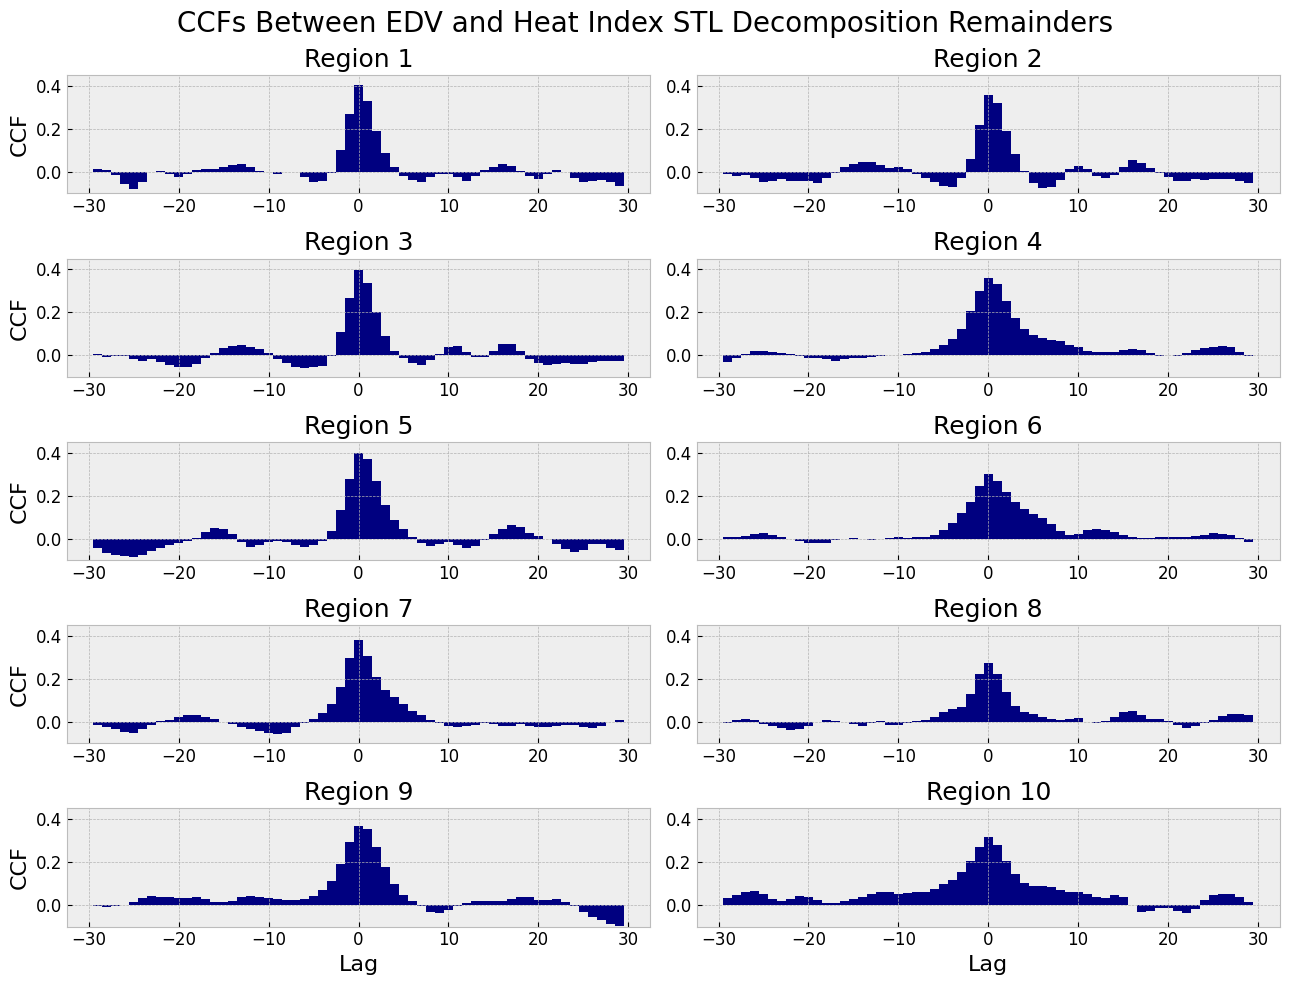

In [6]:
plt.style.use('bmh')
fig, axs = plt.subplots(5, 2, figsize = (13, 10))

covariate_for_title = "Temperature" if COVARIATE == "temp" else "Heat Index"
plt.suptitle(f"CCFs Between EDV and {covariate_for_title} STL Decomposition Remainders",fontsize = 20)

for i, region in enumerate(df.drop(columns = "lags").columns):
    col = i % 2
    row = i // 2
    ax = axs[row, col]

    ax.bar(df.lags, df[region], width = 1, color = "navy")
    ax.set_title(region.replace(".", " "), fontsize = 18)
    ax.set_ylim(-0.1, 0.45)
    if row == 4:
        ax.set_xlabel("Lag", fontsize = 16)
    if col == 0:
        ax.set_ylabel("CCF", fontsize = 16)

    ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()

fig.savefig(OUTPUT_FILE, dpi = 300)